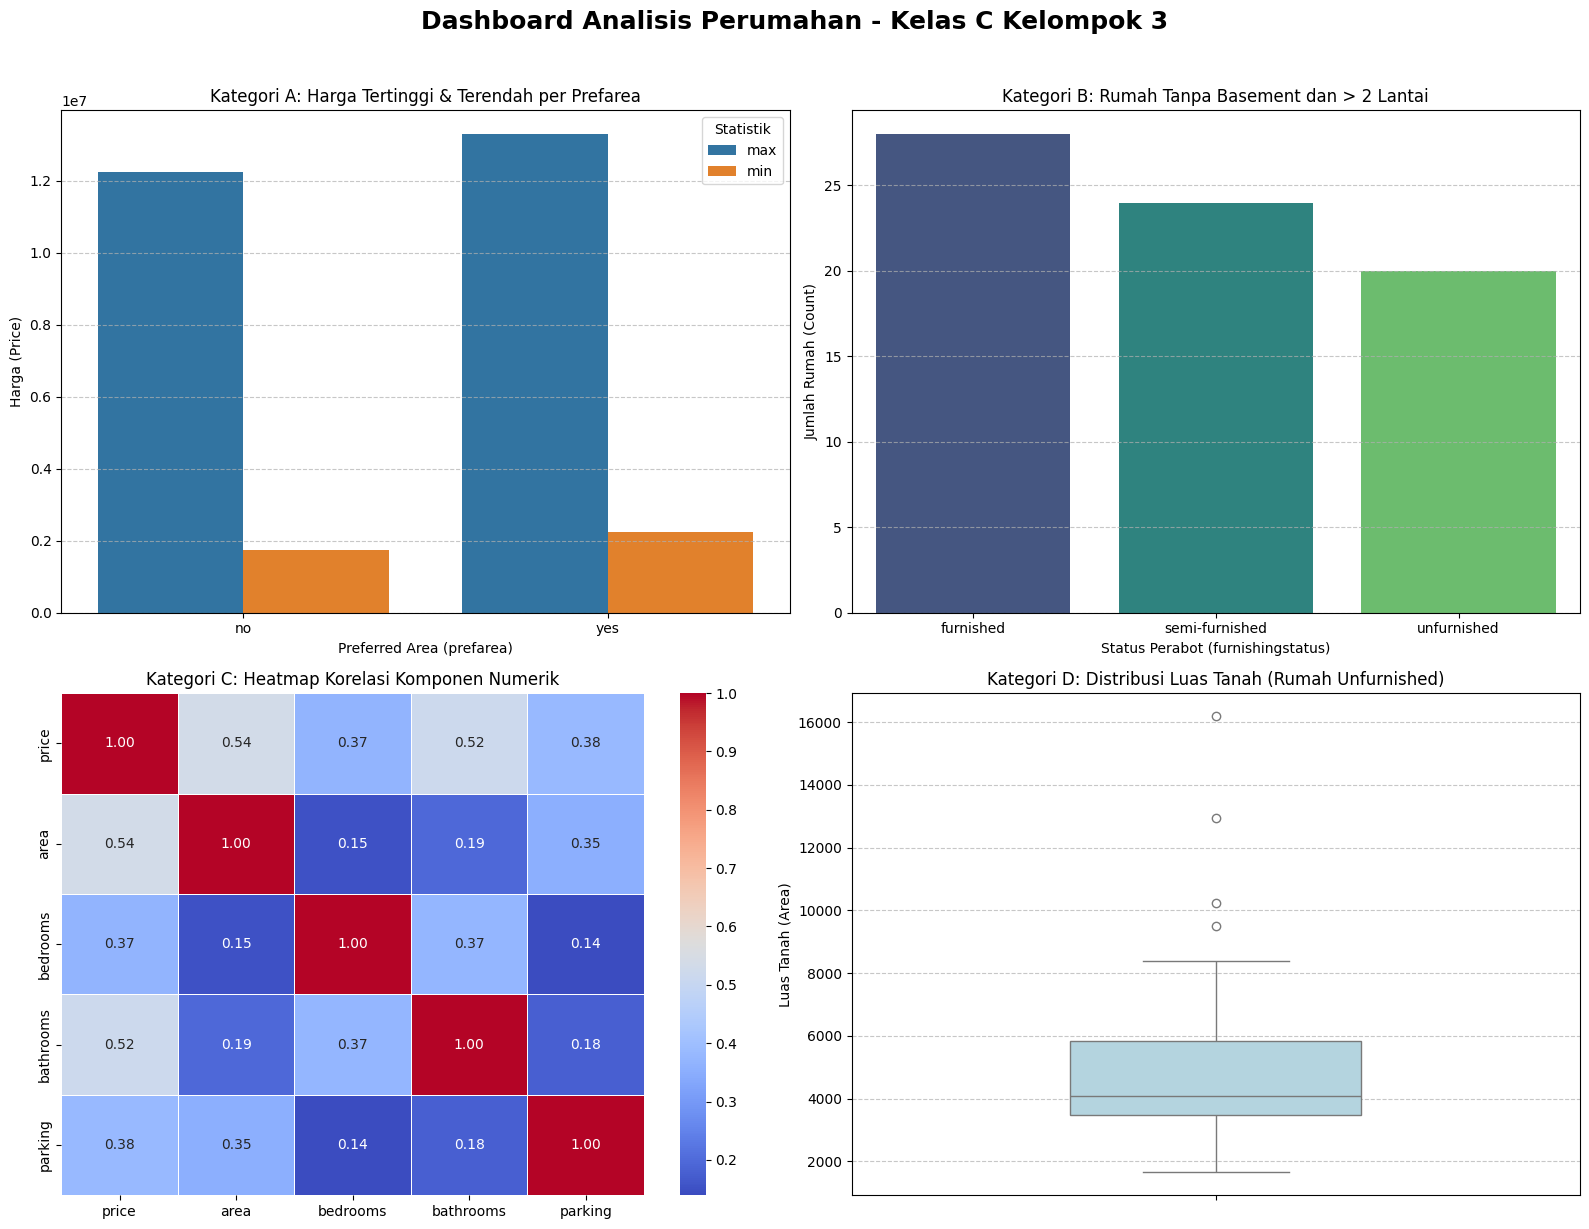

In [1]:
# 1. IMPORT LIBRARY WAJIB
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. MEMUAT DATASET
# Menggunakan nama file verbatim sesuai ketentuan.
df = pd.read_csv('Kelas C_Housing.csv')

# 3. PERSIAPAN FIGURE DAN AXES UNTUK GRAFIK GABUNGAN (GRAFIK 5)
# Membuat grid 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Dashboard Analisis Perumahan - Kelas C Kelompok 3', fontsize=18, fontweight='bold', y=1.02)


# GRAFIK 1 (KATEGORI A) - AGREGASI

# Harga rumah tertinggi dan terendah berdasarkan prefarea dalam Grouped Bar Chart
agg_prefarea = df.groupby('prefarea')['price'].agg(['max', 'min']).reset_index()
agg_prefarea_melted = agg_prefarea.melt(id_vars='prefarea', value_vars=['max', 'min'],
                                        var_name='Statistik', value_name='Price')

sns.barplot(data=agg_prefarea_melted, x='prefarea', y='Price', hue='Statistik',
            ax=axes[0, 0], palette=['#1f77b4', '#ff7f0e'])

axes[0, 0].set_title('Kategori A: Harga Tertinggi & Terendah per Prefarea', fontsize=12)
axes[0, 0].set_xlabel('Preferred Area (prefarea)')
axes[0, 0].set_ylabel('Harga (Price)')
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)



# GRAFIK 2 (KATEGORI B) - TREN / FILTER

# Rumah tanpa basement (basement == 'no') & lantai (stories) > 2. Jumlah berdasarkan status perabot.
filtered_b = df[(df['basement'] == 'no') & (df['stories'] > 2)]
x='furnishingstatus'
sns.countplot(data=filtered_b, x='furnishingstatus', ax=axes[0, 1], palette='viridis', hue=x)

axes[0, 1].set_title('Kategori B: Rumah Tanpa Basement dan > 2 Lantai', fontsize=12)
axes[0, 1].set_xlabel('Status Perabot (furnishingstatus)')
axes[0, 1].set_ylabel('Jumlah Rumah (Count)')
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)



# GRAFIK 3 (KATEGORI C) - KORELASI

# Analisis korelasi antar komponen numerik (price, area, bedrooms, bathrooms, parking) dalam Heatmap
num_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'parking']
corr_matrix = df[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
            ax=axes[1, 0], linewidths=0.5)

axes[1, 0].set_title('Kategori C: Heatmap Korelasi Komponen Numerik', fontsize=12)



# GRAFIK 4 (KATEGORI D) - DISTRIBUSI

# Sebaran data luas tanah (area) untuk rumah 'unfurnished'. Deteksi outlier dengan Boxplot
df_unfurnished = df[df['furnishingstatus'] == 'unfurnished']

sns.boxplot(y=df_unfurnished['area'], ax=axes[1, 1], color='lightblue', width=0.4)

axes[1, 1].set_title('Kategori D: Distribusi Luas Tanah (Rumah Unfurnished)', fontsize=12)
axes[1, 1].set_ylabel('Luas Tanah (Area)')
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.7)



# GRAFIK 5 - PENYELESAIAN TATA LETAK

# Merapikan jarak antar grafik
plt.tight_layout()

# Menampilkan hasil akhir (Grafik 5 yang berisi gabungan Grafik 1-4)
plt.show()